In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from abc import ABC, abstractmethod
import numpy as np
from sklearn.metrics import classification_report, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVR, SVC
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']
Признаков: 16, Объектов: 13611
3    3546
6    2636
5    2027
4    1928
2    1630
0    1322
1     522
Name: count, dtype: int64


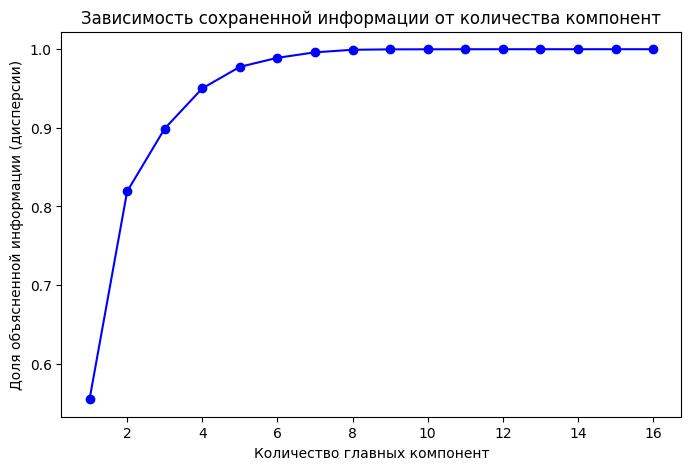

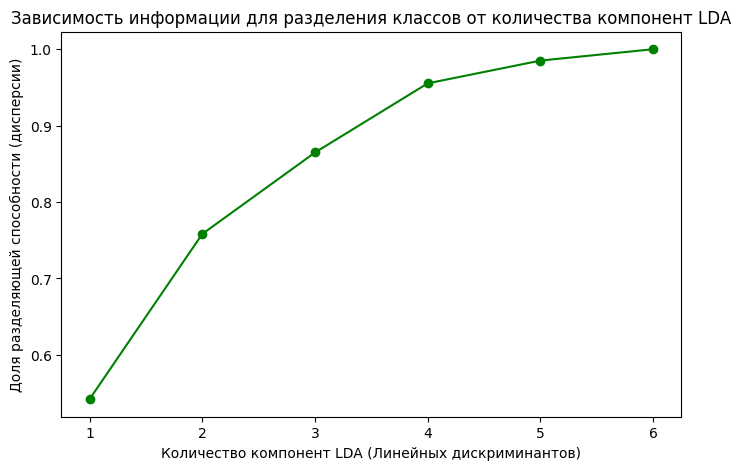

In [23]:
data = pd.read_csv('Dry_Bean_Dataset.csv', delimiter=';', decimal=',')
print(data.columns.tolist())
data = data.dropna(axis=1, how='all')  
data.fillna(data.mean(numeric_only=True), inplace=True)
X = data.drop(['Class'], axis=1).values
le = LabelEncoder()
y = le.fit_transform(data['Class'].values)



print(f"Признаков: {X.shape[1]}, Объектов: {X.shape[0]}")

print(pd.Series(y).value_counts())



scaler = StandardScaler()
X = scaler.fit_transform(X)
################################
pca = PCA()
X_pca = pca.fit_transform(X) 

cumulative_info = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))

plt.plot(range(1, len(cumulative_info) + 1), cumulative_info, marker='o', color='b', linestyle='-')

plt.xlabel('Количество главных компонент')
plt.ylabel('Доля объясненной информации (дисперсии)')
plt.title('Зависимость сохраненной информации от количества компонент')
plt.show()

pca = PCA(n_components=7)
X_pca = pca.fit_transform(X) 
#########################################
lda = LDA()
lda.fit(X, y)

cumulative_info = np.cumsum(lda.explained_variance_ratio_)

plt.figure(figsize=(8, 5))

plt.plot(range(1, len(cumulative_info) + 1), cumulative_info, marker='o', color='g', linestyle='-')

plt.xlabel('Количество компонент LDA (Линейных дискриминантов)')
plt.ylabel('Доля разделяющей способности (дисперсии)')
plt.title('Зависимость информации для разделения классов от количества компонент LDA')

plt.show()

lda = LDA(n_components=5)
X_lda = lda.fit_transform(X,y) 
#######################################

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)
X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(X_lda, y, test_size=0.2, random_state=42)

In [11]:
model = DecisionTreeClassifier(
    criterion='log_loss',             
    splitter='best',              
    max_depth=10,               
    min_samples_split=2,           
    min_samples_leaf=1,           
    min_weight_fraction_leaf=0.0,  
    max_features=None,            
    random_state=None,            
    max_leaf_nodes=None,           
    min_impurity_decrease=0.0,     
    class_weight='balanced',             
    ccp_alpha=0.0         
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = classification_report(y_test, y_pred)
print(accuracy)

              precision    recall  f1-score   support

           0       0.88      0.87      0.88       261
           1       1.00      1.00      1.00       117
           2       0.90      0.93      0.91       317
           3       0.90      0.90      0.90       671
           4       0.96      0.94      0.95       408
           5       0.95      0.93      0.94       413
           6       0.85      0.87      0.86       536

    accuracy                           0.91      2723
   macro avg       0.92      0.92      0.92      2723
weighted avg       0.91      0.91      0.91      2723



In [12]:
model = DecisionTreeClassifier(
    criterion='log_loss',             
    splitter='best',              
    max_depth=10,               
    min_samples_split=2,           
    min_samples_leaf=1,           
    min_weight_fraction_leaf=0.0,  
    max_features=None,            
    random_state=None,            
    max_leaf_nodes=None,           
    min_impurity_decrease=0.0,     
    class_weight='balanced',             
    ccp_alpha=0.0         
)
model.fit(X_train_pca, y_train_pca)

y_pred = model.predict(X_test_pca)

accuracy = classification_report(y_test_pca, y_pred)
print(accuracy)

              precision    recall  f1-score   support

           0       0.91      0.87      0.89       261
           1       0.99      0.99      0.99       117
           2       0.90      0.96      0.93       317
           3       0.91      0.88      0.89       671
           4       0.96      0.93      0.94       408
           5       0.95      0.93      0.94       413
           6       0.81      0.88      0.84       536

    accuracy                           0.90      2723
   macro avg       0.92      0.92      0.92      2723
weighted avg       0.91      0.90      0.90      2723



In [24]:
model = DecisionTreeClassifier(
    criterion='log_loss',             
    splitter='best',              
    max_depth=10,               
    min_samples_split=2,           
    min_samples_leaf=1,           
    min_weight_fraction_leaf=0.0,  
    max_features=None,            
    random_state=None,            
    max_leaf_nodes=None,           
    min_impurity_decrease=0.0,     
    class_weight='balanced',             
    ccp_alpha=0.0         
)
model.fit(X_train_lda, y_train_lda)

y_pred = model.predict(X_test_lda)

accuracy = classification_report(y_test_lda, y_pred)
print(accuracy)

              precision    recall  f1-score   support

           0       0.94      0.87      0.90       261
           1       1.00      1.00      1.00       117
           2       0.89      0.95      0.92       317
           3       0.92      0.87      0.90       671
           4       0.96      0.94      0.95       408
           5       0.93      0.92      0.92       413
           6       0.82      0.88      0.85       536

    accuracy                           0.91      2723
   macro avg       0.92      0.92      0.92      2723
weighted avg       0.91      0.91      0.91      2723



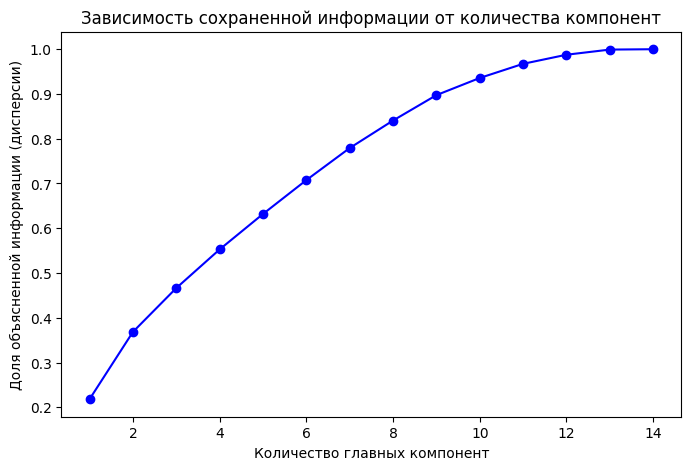

Признаков: 14, Объектов: 17379


In [26]:
data = pd.read_csv('hour.csv')
X = data.drop(['cnt','instant','dteday'], axis=1).values
y = data['cnt'].values

scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)


scaler_y = StandardScaler()
y = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

pca = PCA()
X_pca = pca.fit_transform(X) 


cumulative_info = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))

plt.plot(range(1, len(cumulative_info) + 1), cumulative_info, marker='o', color='b', linestyle='-')

plt.xlabel('Количество главных компонент')
plt.ylabel('Доля объясненной информации (дисперсии)')
plt.title('Зависимость сохраненной информации от количества компонент')
plt.show()

pca = PCA(n_components=11)
X_pca = pca.fit_transform(X) 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

print(f"Признаков: {X.shape[1]}, Объектов: {X.shape[0]}")




Дерево решений для hour

In [6]:
model = DecisionTreeRegressor(
    criterion='squared_error',
    splitter='best',
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=42,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    ccp_alpha=0.0,
    monotonic_cst=None
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

score = model.score(X_test, y_test)
print(score)
mean_absolute_error(y_pred, y_test)

0.9988856383739698


0.018029415484870737

In [15]:
model = DecisionTreeRegressor(
    criterion='squared_error',
    splitter='best',
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=42,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    ccp_alpha=0.0,
    monotonic_cst=None
)

model.fit(X_train_pca, y_train_pca)

y_pred = model.predict(X_test_pca)

score = model.score(X_test_pca, y_test_pca)
print(score)
mean_absolute_error(y_pred, y_test_pca)

0.9192025276906878


0.20176125816298257

Метод опорных векторов для hour

In [7]:
clf = SVR(kernel="rbf", C=1.0, epsilon=0.22).fit(X_train, y_train)
predict = clf.predict(X_test)

clf.score(X_test, y_test)

0.9869514277998975

In [16]:
clf = SVR(kernel="rbf", C=1.0, epsilon=0.22).fit(X_train_pca, y_train_pca)
predict = clf.predict(X_test_pca)

clf.score(X_test_pca, y_test_pca)

0.9891806709192934

Линейная регрессия для hour

In [17]:
clf = LinearRegression().fit(X_train, y_train)
predict = clf.predict(X_test)



clf.score(X_test, y_test)

1.0

In [18]:
clf = LinearRegression().fit(X_train_pca, y_train_pca)
predict = clf.predict(X_test_pca)



clf.score(X_test_pca, y_test_pca)

0.9901757467386392